In [2]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import h5py
import sys
sys.path.append("../src")
import numpy as np
import pandas as pd
import torch
import matplotlib.pylab as plt
# from synthetic_observations import Observations
from realstar_synthetic_observations import Observations

from gaussian_synthetic_observations import Gaussian_Observations
from transformer import *
from spectrum_lsf import Score_Likelihood
from score_models import ScoreModel
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from template import Template
from sbart_rv_finder import RV_Retrieval
from mala import MALA
from matplotlib import gridspec



In [3]:
df4 = pd.read_pickle("../data/SPIRou04_train.df")
df12 = pd.read_pickle("../data/SPIRou12_train.df")
df20 = pd.read_pickle("../data/SPIRou20_train.df")
df29 = pd.read_pickle("../data/SPIRou29_train.df")

In [4]:
non_ones4 = np.where(df4['Wavelength'].iloc[0] != 1)[0]
non_ones12 = np.where(df12['Wavelength'].iloc[0] != 1)[0]
non_ones20 = np.where(df20['Wavelength'].iloc[0] != 1)[0]
non_ones29 = np.where(df29['Wavelength'].iloc[0] != 1)[0]
df4['Wavelength'].iloc[0].shape

(18752,)

In [5]:
non_ones4.shape

(18746,)

In [6]:
flux4 = np.vstack(df4['Final'].to_numpy())
flux4 = flux4[:,non_ones4]
mean4, std4 = np.mean(flux4,axis=0), np.std(flux4,axis=0)

flux20 = np.vstack(df20['Final'].to_numpy())
flux20 = flux20[:,non_ones20]
mean20, std20 = np.mean(flux20,axis=0), np.std(flux20,axis=0)

flux29 = np.vstack(df29['Final'].to_numpy())
flux29 = flux29[:,non_ones29]
mean29, std29 = np.mean(flux29,axis=0), np.std(flux29,axis=0)

flux12 = np.vstack(df12['Final'].to_numpy())
flux12 = flux12[:,non_ones12]
mean12, std12 = np.mean(flux12,axis=0), np.std(flux12,axis=0)

In [7]:
# df4 = None
# df12 =None
# df20 = None
# df29 = None

In [8]:
vdf4 = pd.read_pickle("../data/SPIRou04_val.df")
vdf12 = pd.read_pickle("../data/SPIRou12_val.df")
vdf20 = pd.read_pickle("../data/SPIRou20_val.df")
vdf29 = pd.read_pickle("../data/SPIRou29_val.df")

vdf4_0 = vdf4['Final'].iloc[0]
vdf4_6 = vdf4['Final'].iloc[6]
vdf12_0 = vdf12['Final'].iloc[0]
vdf12_6 = vdf12['Final'].iloc[6]
vdf20_0 = vdf20['Final'].iloc[0]
vdf20_6 = vdf20['Final'].iloc[6]
vdf29_0 = vdf29['Final'].iloc[0]
vdf29_6 = vdf29['Final'].iloc[6]

# vdf4 = None
# vdf12 =None
# vdf20 = None
# vdf29 = None

In [9]:
obs4 = Observations(i=0,N=1,order=4,filepath="../data/SPIRou04_val.df")
obs12 = Observations(i=0,N=1,order=12,filepath="../data/SPIRou12_val.df")
obs20 = Observations(i=0,N=1,order=20,filepath="../data/SPIRou20_val.df")
obs29 = Observations(i=0,N=1,order=29,filepath="../data/SPIRou29_val.df")

/Users/dhvanidoshi/Documents/GitHub/Score_Model_pRV/create_spectra/../src/realstar_synthetic_observations.py:72: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  prox_final = interpolate(torch.tensor(prox_wavelength.to_numpy()).unsqueeze(0).unsqueeze(0), torch.tensor(prox_flux.to_numpy()).unsqueeze(0).unsqueeze(0), torch.tensor(self.wgrid).unsqueeze(0).unsqueeze(0),func='scipy')


here
torch.Size([1, 1, 18746])


/Users/dhvanidoshi/Documents/GitHub/Score_Model_pRV/create_spectra/../src/realstar_synthetic_observations.py:96: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.original_spectrum = torch.tensor(flux_norm,dtype=torch.float64).to(DEVICE).view(1, 1, -1)
/Users/dhvanidoshi/Documents/GitHub/Score_Model_pRV/create_spectra/../src/realstar_synthetic_observations.py:72: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  prox_final = interpolate(torch.tensor(prox_wavelength.to_numpy()).unsqueeze(0).unsqueeze(0), torch.tensor(prox_flux.to_numpy()).unsqueeze(0).unsqueeze(0), torch.tensor(self.wgrid).unsqueeze(0).unsqueeze(0),func='scipy')
/Users/dhvanidoshi/Documents/GitHub/Score_Model_pRV/create_spec

here
torch.Size([1, 1, 18709])


/Users/dhvanidoshi/Documents/GitHub/Score_Model_pRV/create_spectra/../src/realstar_synthetic_observations.py:72: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  prox_final = interpolate(torch.tensor(prox_wavelength.to_numpy()).unsqueeze(0).unsqueeze(0), torch.tensor(prox_flux.to_numpy()).unsqueeze(0).unsqueeze(0), torch.tensor(self.wgrid).unsqueeze(0).unsqueeze(0),func='scipy')
/Users/dhvanidoshi/Documents/GitHub/Score_Model_pRV/create_spectra/../src/realstar_synthetic_observations.py:96: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.original_spectrum = torch.tensor(flux_norm,dtype=torch.float64).to(DEVICE).view(1, 1, -1)


here
torch.Size([1, 1, 18681])
here
torch.Size([1, 1, 18653])


/Users/dhvanidoshi/Documents/GitHub/Score_Model_pRV/create_spectra/../src/realstar_synthetic_observations.py:72: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  prox_final = interpolate(torch.tensor(prox_wavelength.to_numpy()).unsqueeze(0).unsqueeze(0), torch.tensor(prox_flux.to_numpy()).unsqueeze(0).unsqueeze(0), torch.tensor(self.wgrid).unsqueeze(0).unsqueeze(0),func='scipy')
/Users/dhvanidoshi/Documents/GitHub/Score_Model_pRV/create_spectra/../src/realstar_synthetic_observations.py:96: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.original_spectrum = torch.tensor(flux_norm,dtype=torch.float64).to(DEVICE).view(1, 1, -1)


In [10]:
np.median(std4),np.median(std12),np.median(std20),np.median(std29)

(0.09788056907114157,
 0.05270079729891046,
 0.0350043757397029,
 0.07956688406011135)

In [18]:
from astropy.constants import c
def get_dV(A_0,Lambda):
    # Compute the uncertainty
    dAdlam = np.gradient(A_0,Lambda)
    W = (Lambda*dAdlam)**2/A_0
    Q = np.sqrt(np.sum(W))/np.sqrt(np.sum(A_0))
    Ne = np.sum(A_0)

    deltaV = c/(Q*np.sqrt(Ne))
    return deltaV

get_dV(mean4,obs4.wgrid.numpy()),get_dV(mean12,obs12.wgrid.numpy()),get_dV(mean20,obs20.wgrid.numpy()),get_dV(mean29,obs29.wgrid.numpy())

(<Quantity 329.01762303 m / s>,
 <Quantity 460.38467948 m / s>,
 <Quantity 588.98090384 m / s>,
 <Quantity 336.63240091 m / s>)

In [15]:
obs4.wgrid.numpy()

array([1006.95687171, 1006.95854997, 1006.96022823, ..., 1038.9089663 ,
       1038.91069781, 1038.91242933])

In [15]:
import pandas as pd
import numpy as np

# --- Compute zscores for each case ---

# case = 4
zscore4_0 = (mean4 - vdf4_0[non_ones4]) / std4
zscore4_6 = (mean4 - vdf4_6[non_ones4]) / std4
zscore4_p = (mean4 - np.array(obs4.original_spectrum[0,0])) / std4

# case = 12
zscore12_0 = (mean12 - vdf12_0[non_ones12]) / std12
zscore12_6 = (mean12 - vdf12_6[non_ones12]) / std12
zscore12_p = (mean12 - np.array(obs12.original_spectrum[0,0])) / std12

# case = 20
zscore20_0 = (mean20 - vdf20_0[non_ones20]) / std20
zscore20_6 = (mean20 - vdf20_6[non_ones20]) / std20
zscore20_p = (mean20 - np.array(obs20.original_spectrum[0,0])) / std20

# case = 29
zscore29_0 = (mean29 - vdf29_0[non_ones29]) / std29
zscore29_6 = (mean29 - vdf29_6[non_ones29]) / std29
zscore29_p = (mean29 - np.array(obs29.original_spectrum[0,0])) / std29


# --- Summarize into DataFrame ---

data = {
    4: {
        'mean_0': np.mean(zscore4_0),
        'mean_6': np.mean(zscore4_6),
        'mean_p': np.mean(zscore4_p),
        'std_0':  np.std(zscore4_0),
        'std_6':  np.std(zscore4_6),
        'std_p':  np.std(zscore4_p)
    },
    12: {
        'mean_0': np.mean(zscore12_0),
        'mean_6': np.mean(zscore12_6),
        'mean_p': np.mean(zscore12_p),
        'std_0':  np.std(zscore12_0),
        'std_6':  np.std(zscore12_6),
        'std_p':  np.std(zscore12_p)
    },
    20: {
        'mean_0': np.mean(zscore20_0),
        'mean_6': np.mean(zscore20_6),
        'mean_p': np.mean(zscore20_p),
        'std_0':  np.std(zscore20_0),
        'std_6':  np.std(zscore20_6),
        'std_p':  np.std(zscore20_p)
    },
    29: {
        'mean_0': np.mean(zscore29_0),
        'mean_6': np.mean(zscore29_6),
        'mean_p': np.mean(zscore29_p),
        'std_0':  np.std(zscore29_0),
        'std_6':  np.std(zscore29_6),
        'std_p':  np.std(zscore29_p)
    }
}

df = pd.DataFrame.from_dict(data, orient='index')
df.index.name = 'case'

df


,mean_0,mean_6,mean_p,std_0,std_6,std_p
case,,,,,,
4,0.015259,-0.390129,1.642075,0.697356,1.476930,53.829357
12,0.075439,-0.183164,1.259537,0.503906,3.113006,53.627004
20,0.204670,0.041432,0.819728,0.575392,3.030807,36.479536
29,-0.092533,-0.873594,-0.254459,0.440506,3.205774,5.817347


Text(0.5, 1.0, 'Order 4')

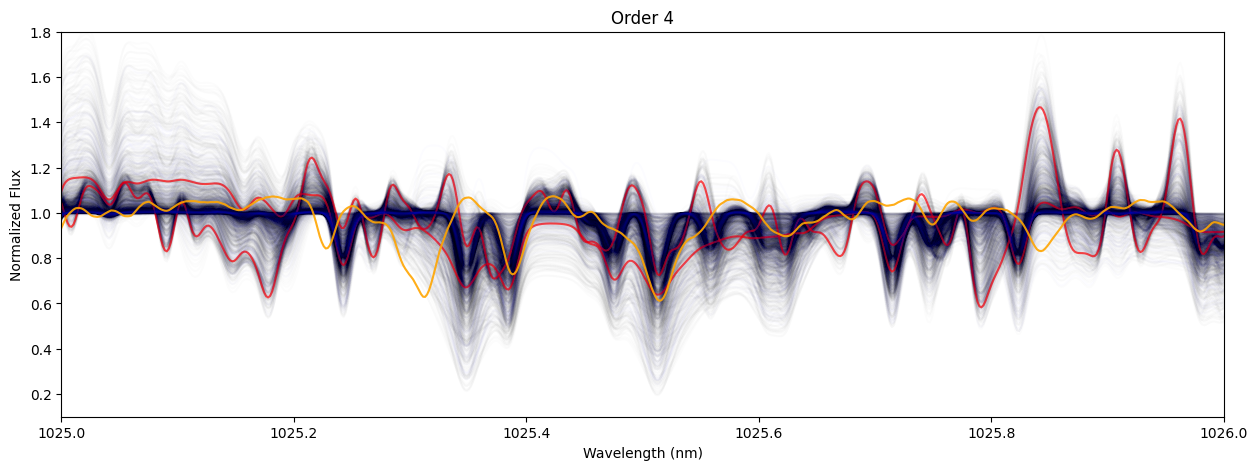

In [11]:
plt.figure(figsize=(15,5))
for i in range(1555):
    plt.plot(obs4.wgrid,df4['Final'].iloc[i][non_ones4],"k",alpha=0.01)

for i in range(300):
    plt.plot(obs4.wgrid,vdf4['Final'].iloc[i][non_ones4],"b",alpha=0.01)
    if i ==0 or i ==6:
        plt.plot(obs4.wgrid,vdf4['Final'].iloc[i][non_ones4],"r",alpha=0.7,label="Validation: "+str(i))
plt.plot(obs4.wgrid,obs4.original_spectrum[0,0]+0.0,"orange",alpha=0.9,label="PROXIMA")

plt.xlim(1025,1026)
plt.ylim(0.1,1.8)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Flux")
plt.title("Order 4")

Text(0.5, 1.0, 'Order 12')

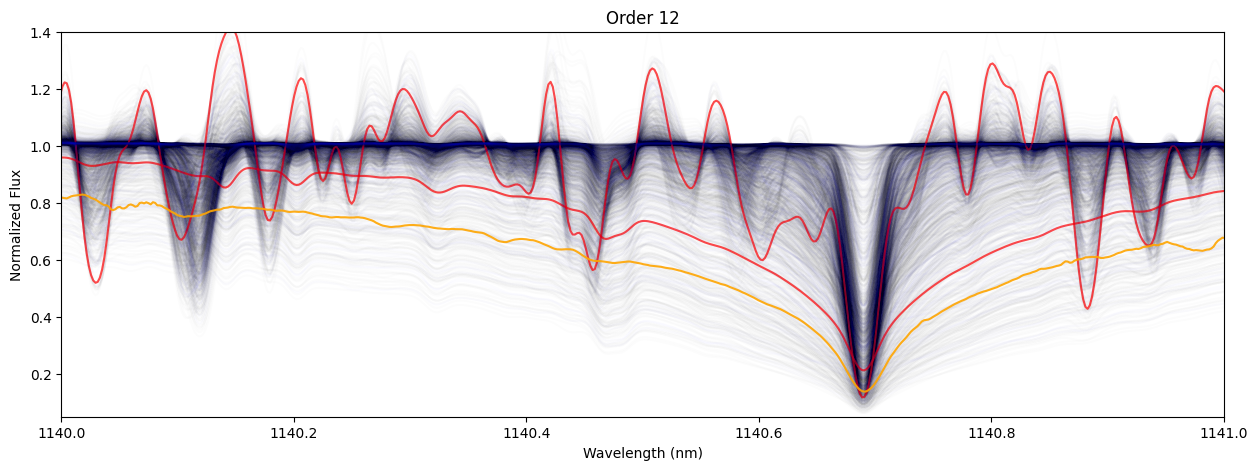

In [12]:
plt.figure(figsize=(15,5))
for i in range(1555):
    plt.plot(obs12.wgrid,df12['Final'].iloc[i][non_ones12],"k",alpha=0.01)

for i in range(300):
    plt.plot(obs12.wgrid,vdf12['Final'].iloc[i][non_ones12],"b",alpha=0.01)
    if i ==0 or i ==6:
        plt.plot(obs12.wgrid,vdf12['Final'].iloc[i][non_ones12],"r",alpha=0.7,label="Validation: "+str(i))
plt.plot(obs12.wgrid,obs12.original_spectrum[0,0]+0.0,"orange",alpha=0.9,label="PROXIMA")

plt.xlim(1140,1141)
plt.ylim(0.05,1.4)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Flux")
plt.title("Order 12")

Text(0.5, 1.0, 'Order 20')

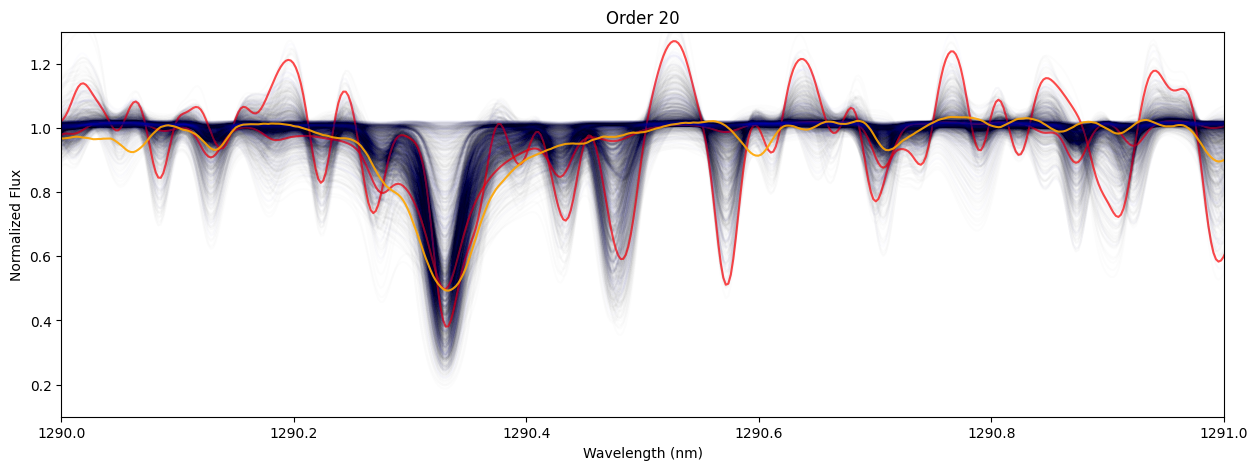

In [13]:
plt.figure(figsize=(15,5))
for i in range(1555):
    plt.plot(obs20.wgrid,df20['Final'].iloc[i][non_ones20],"k",alpha=0.01)

for i in range(300):
    plt.plot(obs20.wgrid,vdf20['Final'].iloc[i][non_ones20],"b",alpha=0.01)
    if i ==0 or i ==6:
        plt.plot(obs20.wgrid,vdf20['Final'].iloc[i][non_ones20],"r",alpha=0.7,label="Validation: "+str(i))
plt.plot(obs20.wgrid,obs20.original_spectrum[0,0]+0.0,"orange",alpha=0.9,label="PROXIMA")

plt.xlim(1290,1291)
plt.ylim(0.1,1.3)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Flux")
plt.title("Order 20")

Text(0.5, 1.0, 'Order 29')

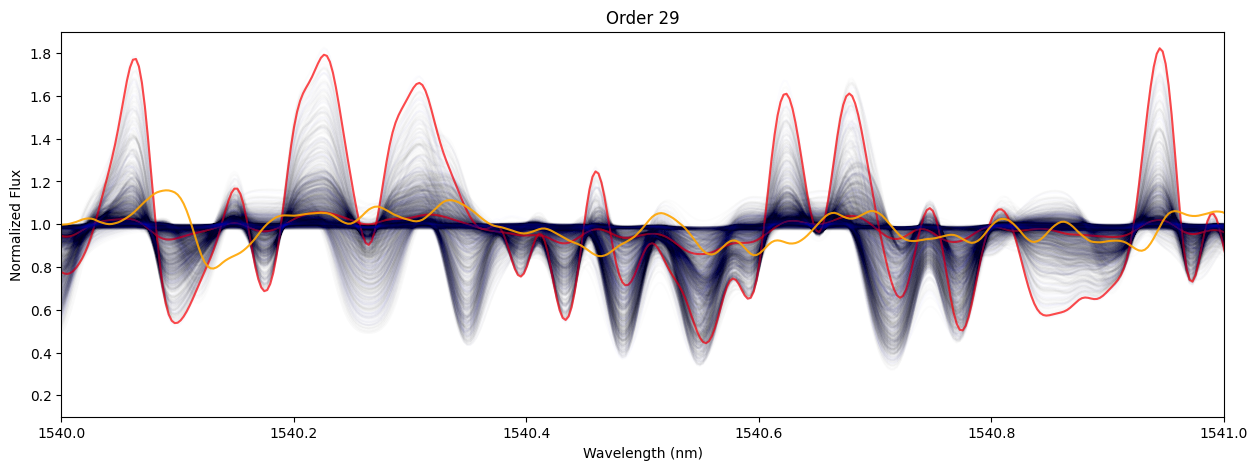

In [14]:
plt.figure(figsize=(15,5))
for i in range(1555):
    plt.plot(obs29.wgrid,df29['Final'].iloc[i][non_ones29],"k",alpha=0.01)

for i in range(300):
    plt.plot(obs29.wgrid,vdf29['Final'].iloc[i][non_ones29],"b",alpha=0.01)
    if i ==0 or i ==6:
        plt.plot(obs29.wgrid,vdf29['Final'].iloc[i][non_ones29],"r",alpha=0.7,label="Validation: "+str(i))
plt.plot(obs29.wgrid,obs29.original_spectrum[0,0]+0.0,"orange",alpha=0.9,label="PROXIMA")

plt.xlim(1540,1541)
plt.ylim(0.1,1.9)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Flux")
plt.title("Order 29")
